In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

In [117]:
df = pd.read_csv("reddit_comments.csv")
df.head()

,post_id,post_title,comment_id,parent_id,author,score,body
0,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt7sbi,t3_1n5j3y0,throwaway6560192,2169,Maybe they want you to do it as an exercise in...
1,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtc2yj,t3_1n5j3y0,Frission_,681,Maybe the point is to show what vulnerabilitie...
2,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt9cor,t3_1n5j3y0,DrShocker,507,Is it concievable they're trying to show you t...
3,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtd4lh,t3_1n5j3y0,COINTELPRO-Relay,432,"Maybe it's some big brain move? Week 1: ""Co..."
4,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtduqf,t3_1n5j3y0,PhilosophicalGoof,101,For a first class assignment? I m guessing thi...


In [118]:
anger = pd.read_csv("anger.txt", sep='\t', header=None, names=['word', 'score'])
anticipation = pd.read_csv("anticipation.txt", sep='\t', header=None, names=['word', 'score'])
disgust = pd.read_csv("disgust.txt", sep='\t', header=None, names=['word', 'score'])
fear = pd.read_csv("fear.txt", sep='\t', header=None, names=['word', 'score'])
joy = pd.read_csv("joy.txt", sep='\t', header=None, names=['word', 'score'])
sadness = pd.read_csv("sadness.txt", sep='\t', header=None, names=['word', 'score'])
surprise = pd.read_csv("surprise.txt", sep='\t', header=None, names=['word', 'score'])
trust = pd.read_csv("trust.txt", sep='\t', header=None, names=['word', 'score'])


anger_lexicon = set(anger[anger["score"] == 1]["word"].astype(str).str.lower().str.strip())
anticipation_lexicon = set(anticipation[anticipation["score"] == 1]["word"].astype(str).str.lower().str.strip())
disgust_lexicon = set(disgust[disgust["score"] == 1]["word"].astype(str).str.lower().str.strip())
fear_lexicon = set(fear[fear["score"] == 1]["word"].astype(str).str.lower().str.strip())
joy_lexicon = set(joy[joy["score"] == 1]["word"].astype(str).str.lower().str.strip())
sadness_lexicon = set(sadness[sadness["score"] == 1]["word"].astype(str).str.lower().str.strip())
surprise_lexicon = set(surprise[surprise["score"] == 1]["word"].astype(str).str.lower().str.strip())
trust_lexicon = set(trust[trust["score"] == 1]["word"].astype(str).str.lower().str.strip())



In [119]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)  # hapus HTML tag
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hapus karakter non huruf
    text = re.sub(r'([a-zA-Z])\1\1','\1',text) # Hapus duplikasi tiga karakter beruntun
    text = re.sub(r' +',' ',text) # Hapus spasi ganda
    text = re.sub(r'^[ ]|[ ]$','',text) # Hapus spasi di awal dan akhir kalimat
    text = text.lower()  # ubah ke huruf kecil
    return text

#texts = texts.apply(clean_text)

In [120]:
df['body'].astype(str)
df['clean_text'] = df['body'].apply(clean_text)
df.head()
     

,post_id,post_title,comment_id,parent_id,author,score,body,clean_text
0,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt7sbi,t3_1n5j3y0,throwaway6560192,2169,Maybe they want you to do it as an exercise in...,maybe they want you to do it as an exercise in...
1,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtc2yj,t3_1n5j3y0,Frission_,681,Maybe the point is to show what vulnerabilitie...,maybe the point is to show what vulnerabilitie...
2,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt9cor,t3_1n5j3y0,DrShocker,507,Is it concievable they're trying to show you t...,is it concievable they re trying to show you t...
3,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtd4lh,t3_1n5j3y0,COINTELPRO-Relay,432,"Maybe it's some big brain move? Week 1: ""Co...",maybe it s some big brain move week code slop ...
4,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtduqf,t3_1n5j3y0,PhilosophicalGoof,101,For a first class assignment? I m guessing thi...,for a first class assignment i m guessing this...


In [121]:
def get_emotion_label(text):
    # 1. Pecah kalimat jadi kata-kata (tokenization sederhana)
    words = str(text).lower().split()
    
    # 2. Inisialisasi skor untuk tiap emosi
    scores = {
        'anger': 0, 'anticipation': 0, 'disgust': 0, 'fear': 0,
        'joy': 0, 'sadness': 0, 'surprise': 0, 'trust': 0
    }
    
    # 3. Hitung kecocokan kata dengan lexicon
    for word in words:
        if word in anger_lexicon: scores['anger'] += 1
        if word in anticipation_lexicon: scores['anticipation'] += 1
        if word in disgust_lexicon: scores['disgust'] += 1
        if word in fear_lexicon: scores['fear'] += 1
        if word in joy_lexicon: scores['joy'] += 1
        if word in sadness_lexicon: scores['sadness'] += 1
        if word in surprise_lexicon: scores['surprise'] += 1
        if word in trust_lexicon: scores['trust'] += 1
            
    # 4. Ambil emosi dengan skor tertinggi
    # Jika semua skor 0, beri label 'neutral'
    if max(scores.values()) == 0:
        return 'neutral'
    
    return max(scores, key=scores.get)

# 5. Terapkan ke dataset
df['label'] = df['clean_text'].apply(get_emotion_label)

In [122]:
df['label'] = df['clean_text'].apply(get_emotion_label)
df.tail()

,post_id,post_title,comment_id,parent_id,author,score,body,clean_text,label
329,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncec38m,t1_ncdgbi4,dragostego,1,"Politely, when you are trying to make the argu...",politely when you are trying to make the argum...,trust
330,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ng3an73,t1_nbye7v5,Ape-Hard,1,Any student who sends you that doesn't care if...,any student who sends you that doesn t care if...,neutral
331,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbvoerd,t1_nbvmrp0,Moviesman8,2,That's fair. Thanks for replying.,that s fair thanks for replying,neutral
332,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncejpee,t1_ncec38m,ILLBEON_economy_tool,1,No it’s more that I’m trying to help a bunch o...,no it s more that i m trying to help a bunch o...,anticipation
333,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncffqh0,t1_ncec38m,ILLBEON_economy_tool,1,"Like, is this what happened with the internet?...",like is this what happened with the internet i...,neutral


In [123]:
emotions_counts = df['label'].value_counts()
emotions_counts
     

label
trust           94
neutral         81
anticipation    71
anger           39
fear            14
joy             13
disgust          8
surprise         8
sadness          6
Name: count, dtype: int64

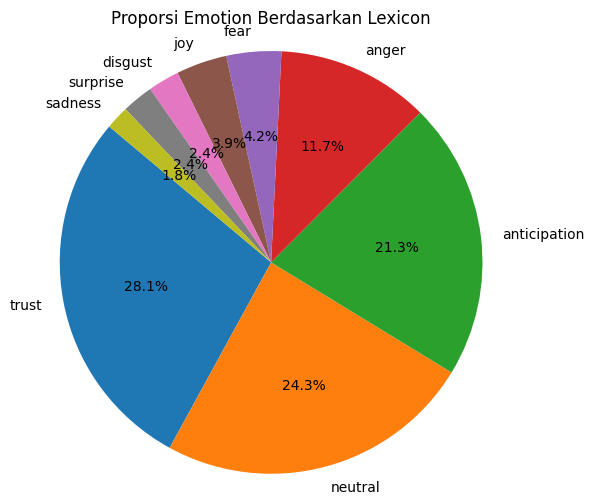

In [124]:
#Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    emotions_counts,
    labels=emotions_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Proporsi Emotion Berdasarkan Lexicon')
plt.axis('equal')
plt.show()
     

In [125]:
def generate_wordcloud(text_series, title):
    text = " ".join(text_series)
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

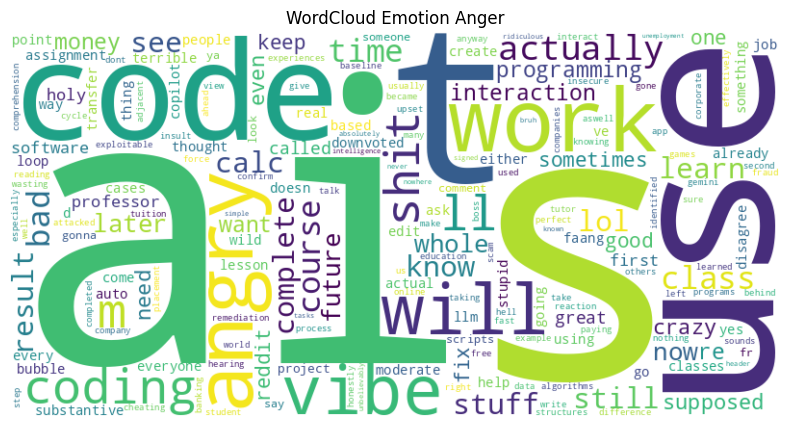

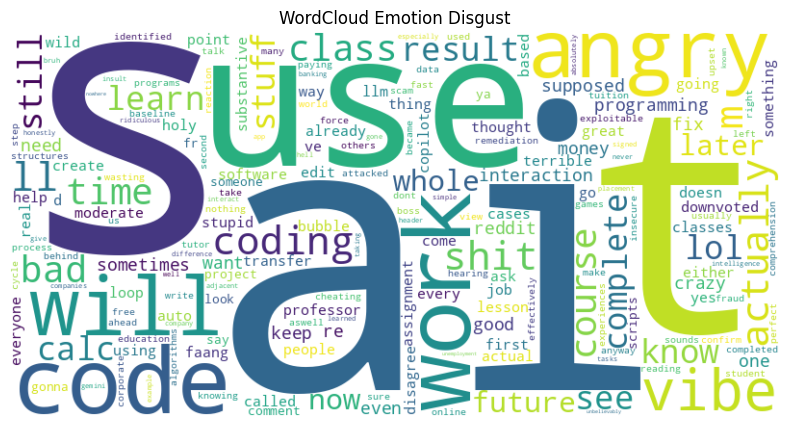

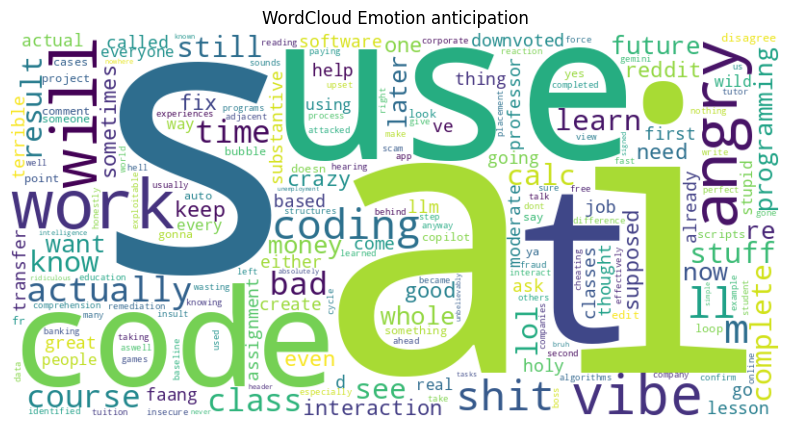

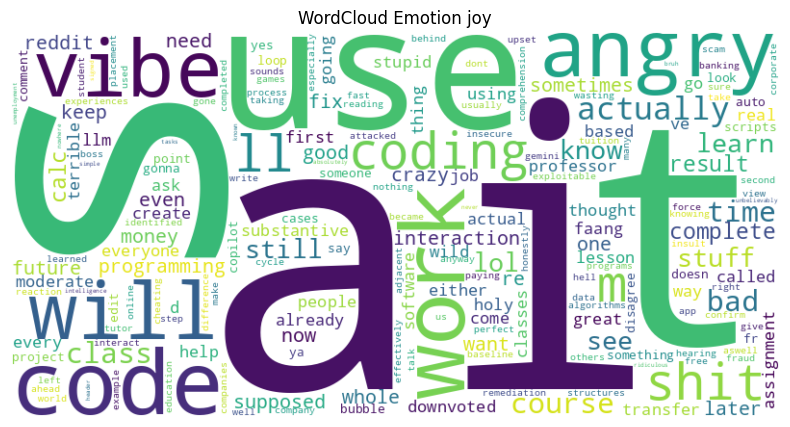

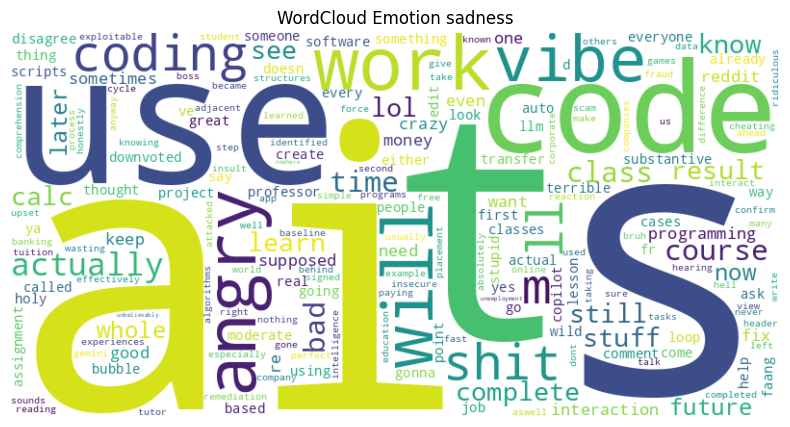

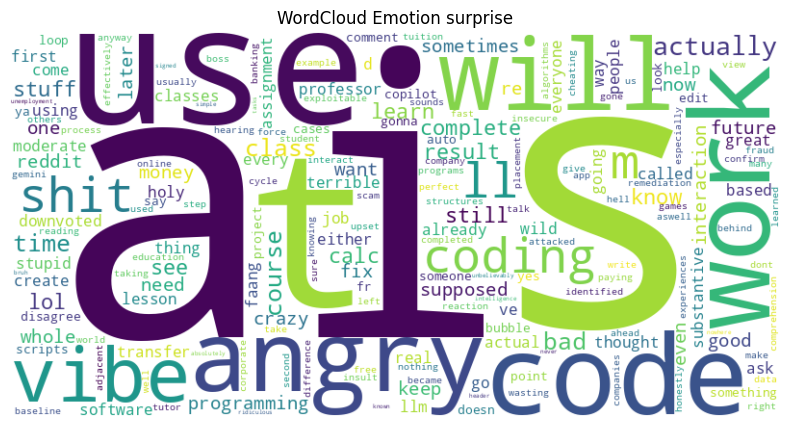

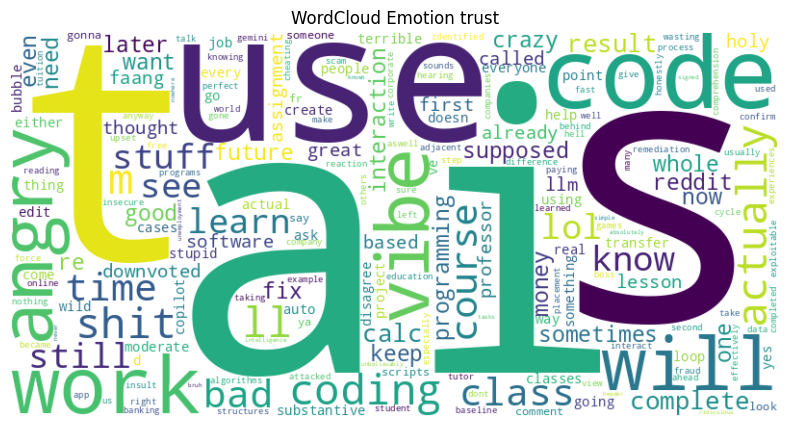

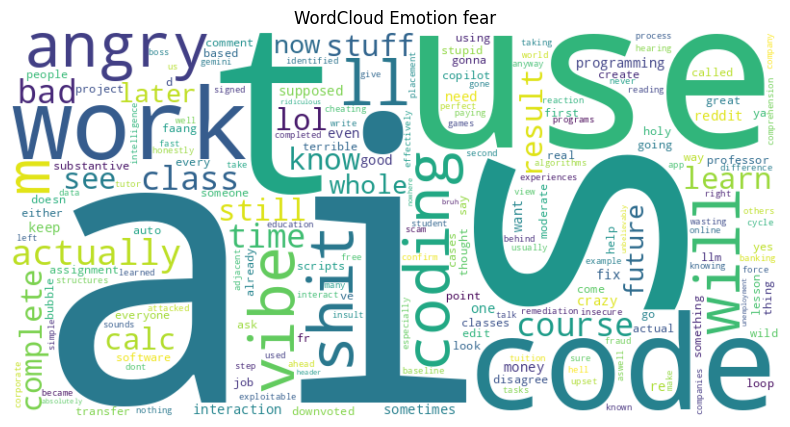

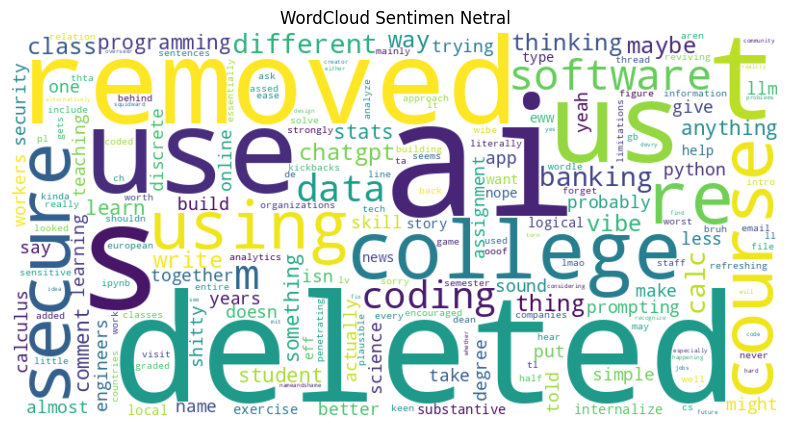

In [126]:
anger_text = df[df['label'] == 'anger']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion Anger")

disgust_text = df[df['label'] == 'disgust']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion Disgust")

anticipation_text = df[df['label'] == 'anticipation']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion anticipation")

joy_text = df[df['label'] == 'joy']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion joy")

sadness_text = df[df['label'] == 'sadness']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion sadness")

surprise_text = df[df['label'] == 'surprise']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion surprise")

trust_text = df[df['label'] == 'trust']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion trust")

fear_text = df[df['label'] == 'fear']['clean_text']
generate_wordcloud(anger_text, "WordCloud Emotion fear")


# Wordcloud untuk sentimen netral
neutral_text = df[df['label'] == 'neutral']['clean_text']
generate_wordcloud(neutral_text, "WordCloud Sentimen Netral")

In [ ]:
df.to_csv("reddit_comments_labeled.csv", index=False)
     